In [4]:
import pandas as pd
import os

# Load the Truth file
truth_path = os.path.join(r"c:\Python\Personal\kfm-ms\codes\pest\master_run", "master_truth.csv")
df_truth = pd.read_csv(truth_path)

# Extract unique well locations in the order of their ID
truth_locs = df_truth.sort_values("well_id")[['r', 'c']].drop_duplicates().values.tolist()

print("Well Locations in Truth File (sorted by well_id):")
for i, loc in enumerate(truth_locs):
    print(f"ID {i}: {loc}")


Well Locations in Truth File (sorted by well_id):
ID 0: [56, 31]
ID 1: [42, 42]
ID 2: [35, 56]
ID 3: [44, 43]
ID 4: [82, 31]
ID 5: [63, 43]
ID 6: [56, 61]
ID 7: [79, 33]
ID 8: [31, 48]
ID 9: [85, 34]
ID 10: [32, 49]
ID 11: [30, 37]
ID 12: [50, 37]
ID 13: [42, 40]
ID 14: [54, 53]
ID 15: [80, 36]
ID 16: [71, 61]
ID 17: [70, 47]
ID 18: [53, 59]
ID 19: [52, 43]


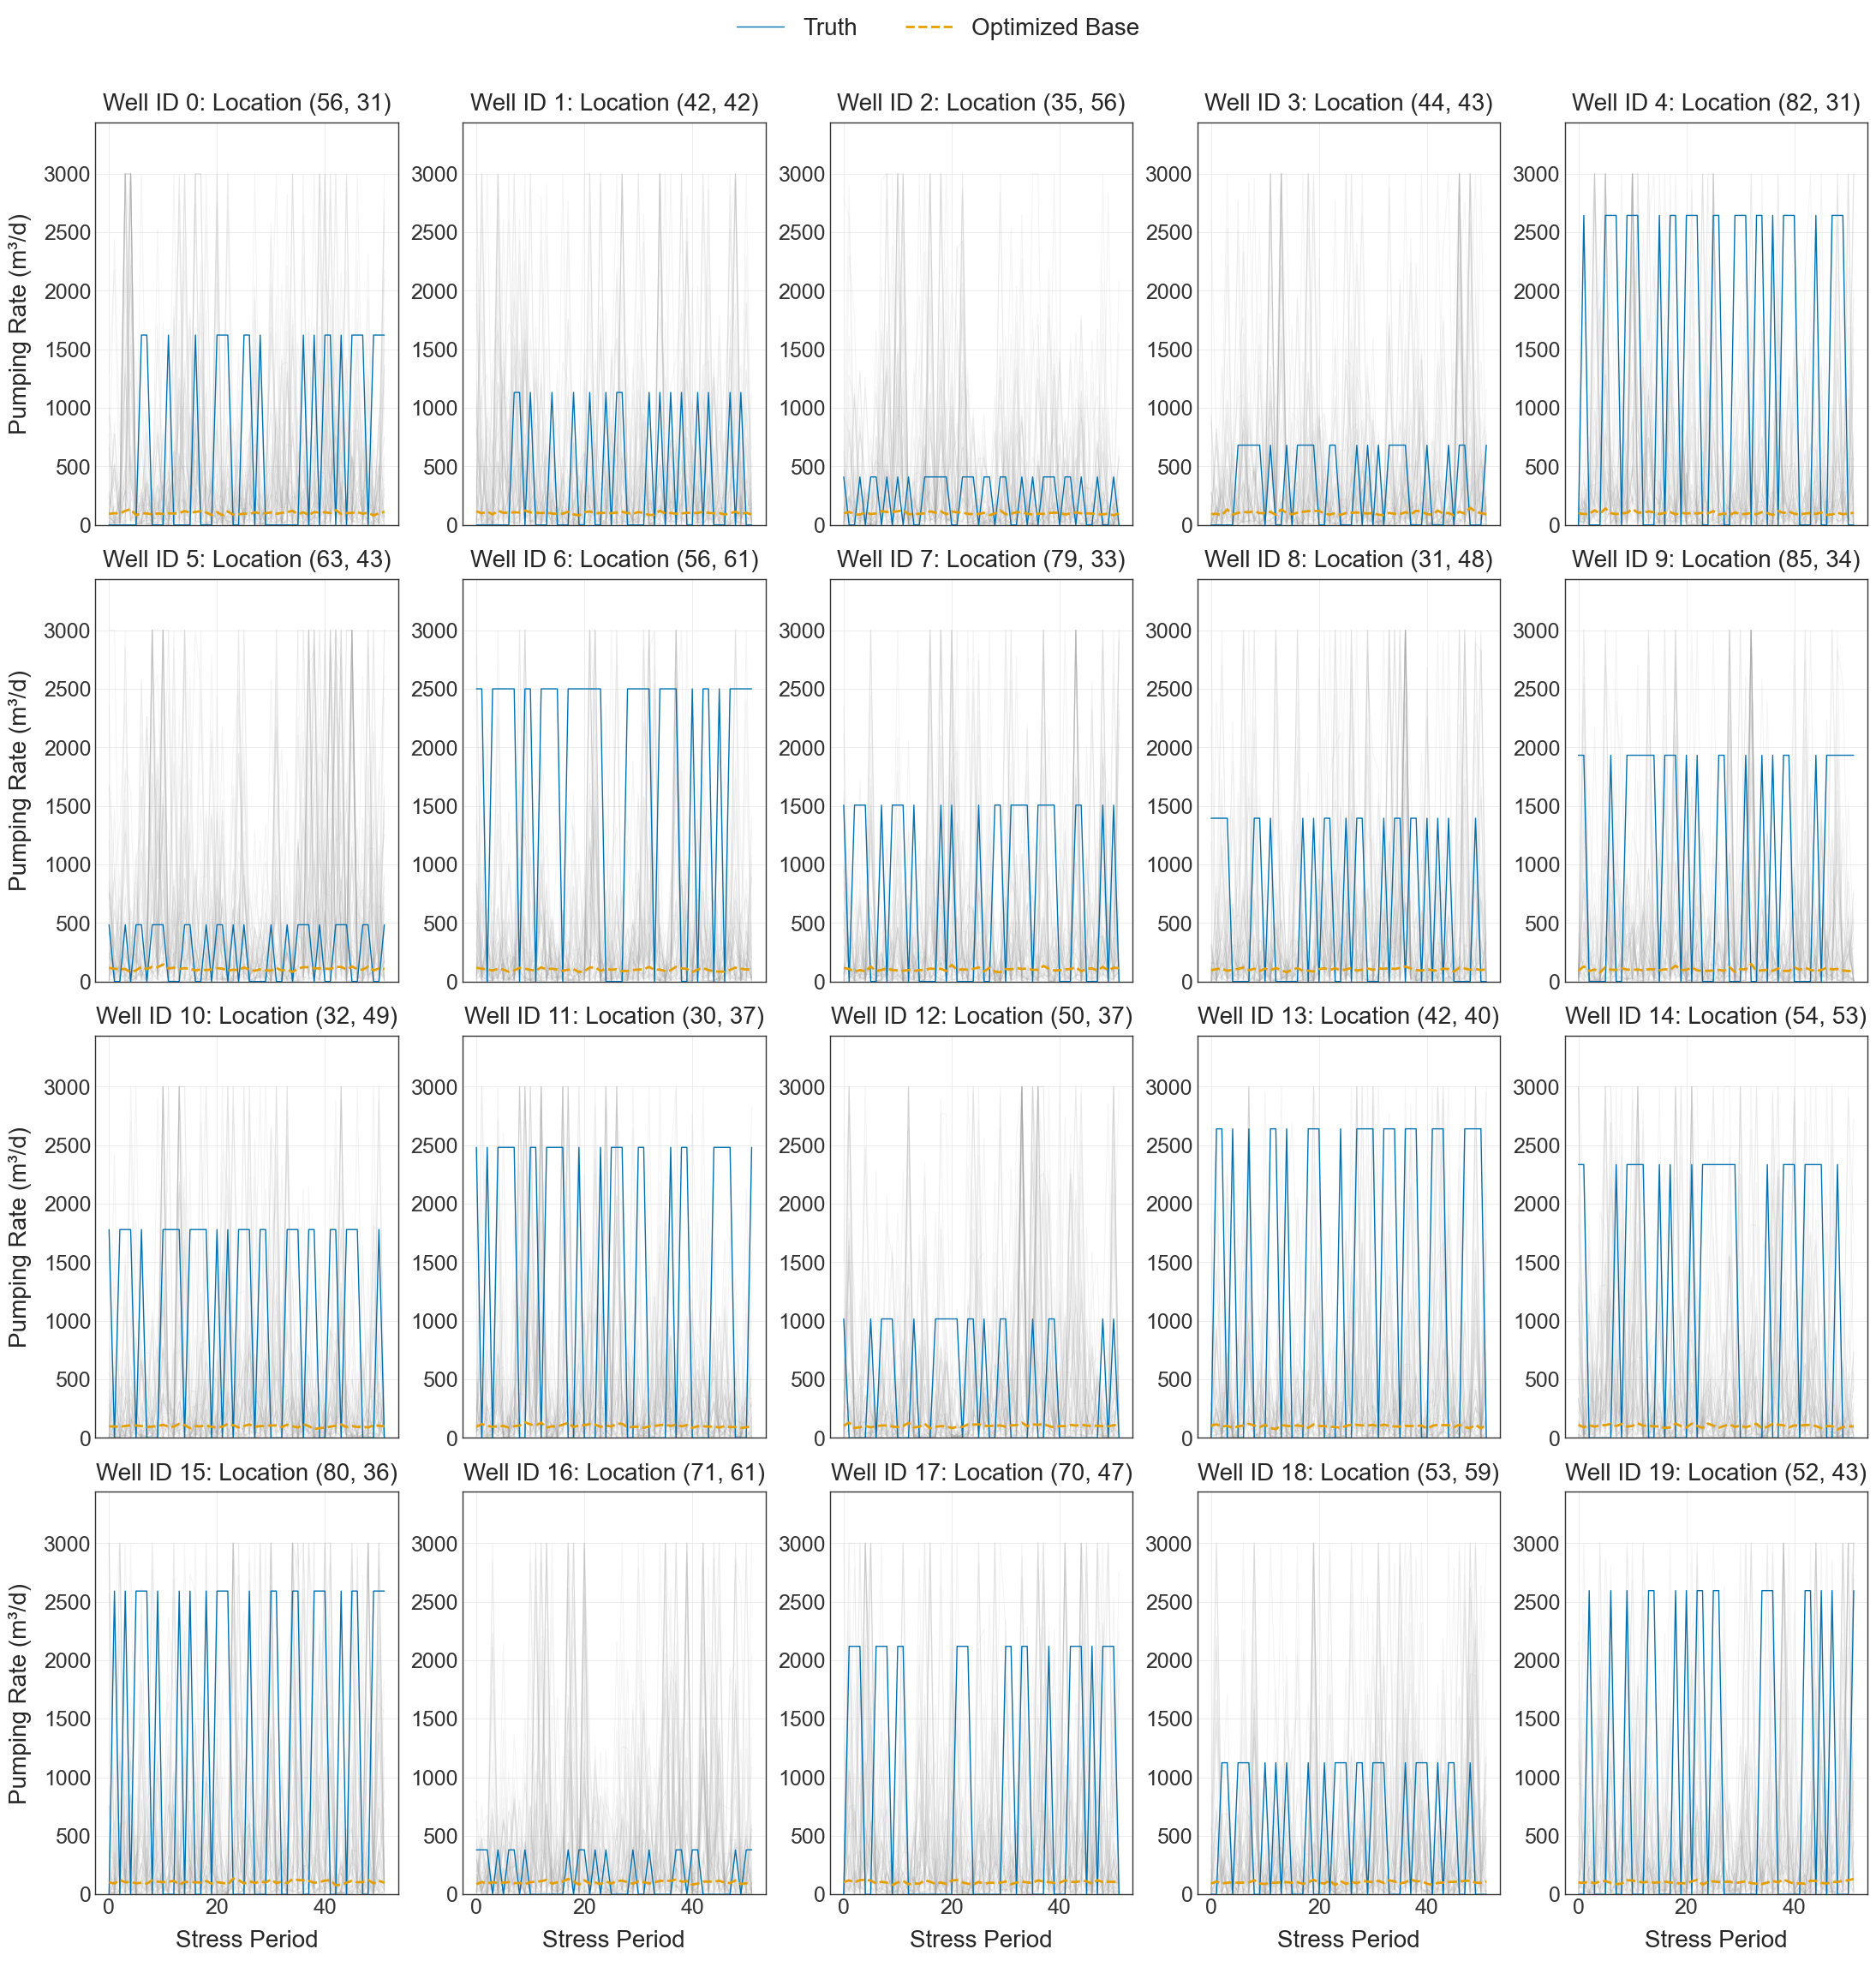

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --- 1. SET GLOBAL SIZING & TYPOGRAPHY PARAMETERS ---
size = 24  
mpl.rcParams['font.family'] = 'Arial'

PEST_DIR = r"c:\Python\Personal\kfm-ms\codes\pest\master_run"

# load data
df_truth = pd.read_csv(os.path.join(PEST_DIR, "master_truth.csv"))
df_pars = pd.read_csv(os.path.join(PEST_DIR, "inversion_level_1.1.par.csv"), index_col=0)

# identify unique wells sorted by ID
unique_wells = df_truth.sort_values("well_id")[['well_id', 'r', 'c']].drop_duplicates()
num_wells = len(unique_wells)

# automatically calculate rows to fit all unique wells into a 5-column layout
num_cols = 5
num_rows = (num_wells + 1) // num_cols

# Dynamic canvas sizing: matches the 11x10 base aspect ratio scaled by row count
fig, axes = plt.subplots(num_rows, num_cols, figsize=(22, num_rows * 5.5), sharex=True)
axes = axes.flatten()

# track maximum rate for padding the shared layout scale
global_q_max = df_truth['q'].max() if df_truth['q'].max() > 0 else 100.0

# --- 2. ITERATE AND FORMAT SUBPLOT PANELS ---
for i, (_, row) in enumerate(unique_wells.iterrows()):
    ax = axes[i]
    w_id, r, c = int(row.well_id), int(row.r), int(row.c)
    well_tag = f"r:{r}_c:{c}"
    
    # Clean canvas initialization matching target style
    ax.set_facecolor('white')
    ax.grid(True, color="#E6E6E6", linestyle="-", linewidth=0.5, zorder=0)
    
    # Ensure standard sharp black bounding box frame
    for spine in ax.spines.values():
        spine.set_color('#333333')
        spine.set_linewidth(1.0)
    
    # extract and sort parameter columns sequentially by Stress Period (sp)
    well_cols = [col for col in df_pars.columns if well_tag in col]
    well_cols.sort(key=lambda x: int(x.split("sp:")[1].split("_")[0]))
    
    # plot posterior ensemble realizations (light gray backgrounds)
    for real in df_pars.index:
        if real != 'base':
            ax.plot(df_pars.loc[real, well_cols].values, color="#999999", alpha=0.1, linewidth=0.8, zorder=1)
        
    # plot true target operational history using high-visibility consulting blue (linewidth adjusted to 1.0)
    truth_q = df_truth[(df_truth.well_id == w_id)].sort_values("sp").q.values
    ax.plot(truth_q, label="Truth" if i == 0 else "", color='#0072B2', marker='none', linewidth=1.0, zorder=10)
    
    # plot final optimized base run solution (amber orange marker line)
    base_q = df_pars.loc['base', well_cols]
    ax.plot(base_q.values, label="Optimized Base" if i == 0 else "", color='#E69F00', linestyle='--', linewidth=2.0, zorder=11)
    
    # Panel Header formatting (Using matching target size and normal weight hierarchy)
    ax.set_title(f"Well ID {w_id}: Location ({r}, {c})", fontsize=size-4, fontweight='normal', pad=10)
    ax.set_ylim(0, global_q_max * 1.3)  # Clean upper breathing bounds matching template style
    
    # Axis ticks configuration
    ax.tick_params(axis='both', which='major', labelsize=size-6, colors='#333333')
    
    # Multi-row label stripping strategy
    if i % num_cols == 0:
        ax.set_ylabel("Pumping Rate (m³/d)", fontsize=size-4, labelpad=10)
    if i >= (num_wells - num_cols):
        ax.set_xlabel("Stress Period", fontsize=size-4, labelpad=10)

# Cleanly delete hanging subplots if your target well count is odd
for j in range(num_wells, len(axes)):
    fig.delaxes(axes[j])

# --- 3. GLOBAL MASTER LEGEND OVERLAY ---
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(
        handles, labels, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 1.01), 
        ncol=2, 
        facecolor='white', 
        edgecolor='none', 
        framealpha=1, 
        fontsize=size-4
    )

# --- 4. EXPORT AND RENDER ---
plt.tight_layout()
plt.savefig(f"Level1_MultiPanel_Results.svg", dpi=300, bbox_inches='tight')
plt.show()